In [ ]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

## Helper functions

In [9]:

'''     
    Helper functions for loading and displaying images. 
'''
def load_image_rgb(path):
    """
        Load an image using OpenCV hence why it needs to be converted into RGB format because 
        OpenCV loads images in BGR format by default
    """
    image = cv2.imread(path)

    if image is None:
        raise FileNotFoundError(f"Could not load image from path: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

def display_images(items, cmaps=None, figsize=None, suptitle=None):
    n = len(items)

    if figsize is None:
        figsize = (5 * n, 4)

    if cmaps is None:
        cmaps = [None] * n

    fig, axes = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axes = [axes]

    for ax, (img, title), cmap in zip(axes, items, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

## Loading the Raw Image

The first step is to load the original image. OpenCV loads images in BGR format, meaning the colour channels are ordered as Blue, Green, Red.

However, Matplotlib expects images in RGB format, meaning Red, Green, Blue.

So after loading the image with `cv2.imread`, we convert it using `cv2.cvtColor`.

This gives us the correct raw image that we will use throughout the watershed pipeline.

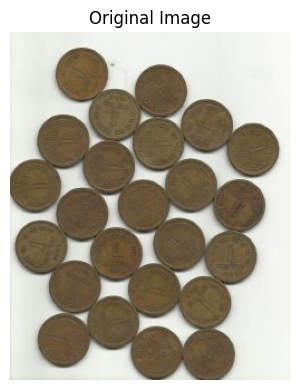

In [10]:
raw_image = load_image_rgb("images/water_coins.jpg")
display_images([(raw_image, "Original Image")])

## Converting the Image to Grayscale

The raw image is an RGB image, so each pixel has three colour values: red, green, and blue.

For watershed segmentation, we usually simplify the image into grayscale. In grayscale, each pixel has only one intensity value.

This is useful because the next steps, such as thresholding and gradient computation, work more naturally on intensity values rather than full colour values.

At this point, we are not separating objects yet. We are only simplifying the image representation.

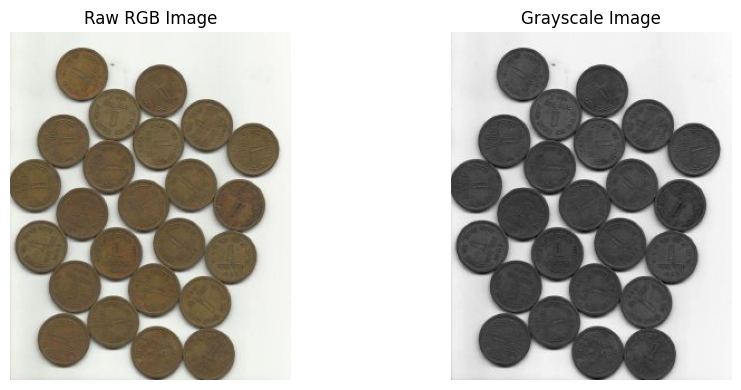

In [ ]:
gray_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2GRAY)

display_images([(raw_image, "Raw RGB Image"), (gray_image, "Grayscale Image")], cmaps=[None, "gray"])

## Creating a Binary Image

The grayscale image still contains many different intensity values between 0 and 255.

To prepare for watershed segmentation, we first create a binary image from the grayscale image. A binary image only has two main values: black and white.

The white pixels represent the foreground objects that we want to segment because, in `cv2.threshold`, we pass `255` as the value assigned to pixels that satisfy the thresholding condition. Since `255` appears as white in a binary image, those selected pixels become the foreground. The remaining pixels are assigned `0`, which appears as black and represents the background.

Here, Otsu thresholding is used. Instead of manually choosing a threshold value, Otsu's method automatically finds a threshold that separates darker and brighter regions in the image. This happens because of the `cv2.THRESH_OTSU` flag.

Usint the `cv2.THRESH_BINARY_INV` flag, means inverse binary thresholding. This means that pixels darker than the threshold become white, while pixels brighter than the threshold become black. The inverse version is being used because the objects being segmented are darker than the background. This makes the objects appear as white foreground regions and the background appear black.

This step is important because the binary image will later be used to compute the distance transform and generate markers. Before moving on, I check that the objects I want to segment are white and the background is black.

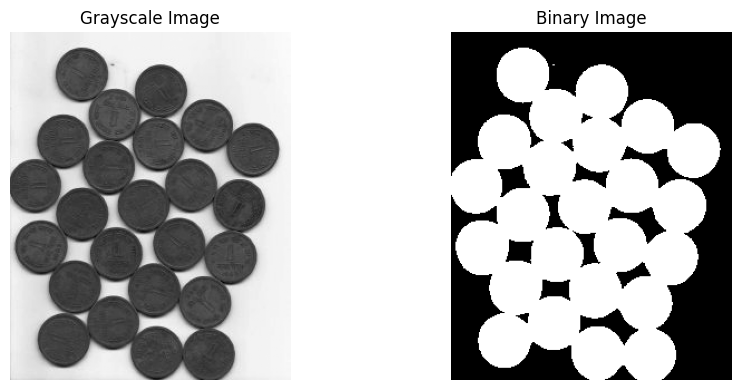

Otsu threshold value: 162.0


In [14]:
threshold_value, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

display_images([(gray_image, "Grayscale Image"), (binary_image, "Binary Image")], cmaps=["gray", "gray"])

print("Otsu threshold value:", threshold_value)

## Applying the Distance Transform

After creating the binary image, I apply the distance transform.

The binary image tells us which pixels belong to the foreground and which pixels belong to the background. In this case, the white pixels represent the foreground objects, while the black pixels represent the background.

The distance transform looks at each white foreground pixel and calculates how far it is from the nearest black background pixel.

In this implementation, `cv2.DIST_L2` is used, which means the distance is estimated using Euclidean distance. In simple terms, this measures distance in the normal straight-line way.

The value `5` is the mask size, which means OpenCV uses a `5×5` neighbourhood mask when estimating the distance. Compared to a smaller `3×3` mask, this can give a more accurate approximation of the Euclidean distance.

This means pixels near the object boundary will have smaller distance values, while pixels closer to the centre of the object will have larger distance values.

This is useful for watershed segmentation because the centre of each object is usually a more reliable place to start flooding from. These high-distance regions will later help us create the sure foreground markers.

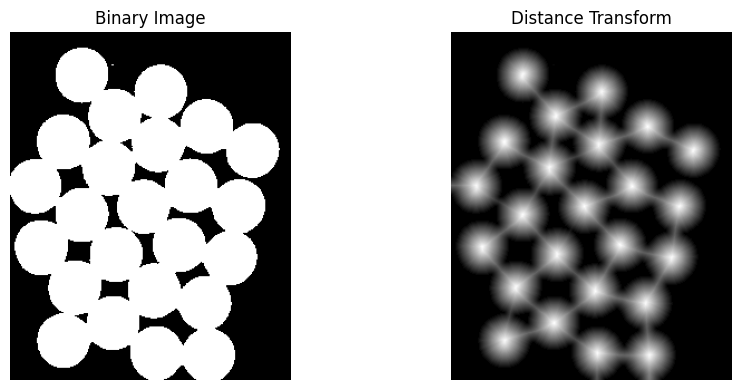

In [15]:
distance_transform = cv2.distanceTransform(binary_image, cv2.DIST_L2, 5)

display_images([(binary_image, "Binary Image"), (distance_transform, "Distance Transform")], cmaps=["gray", "gray"])

## Creating the Sure Foreground

The distance transform gives larger values to pixels that are closer to the centre of the foreground objects.

To create reliable object seeds, I threshold the distance transform. This keeps only the pixels with high distance values, which are usually near the centre of each object.

These selected regions are called the sure foreground because they are very likely to belong to the objects and not to the background.

The threshold is chosen as a percentage of the maximum distance value. For example, using `0.5 * distance_transform.max()` means we keep only pixels whose distance value is at least 50% of the maximum distance found in the image.

If the percentage is too low, the foreground markers may become too large and merge together. If the percentage is too high, the markers may become too small or disappear.

These sure foreground regions will later be labelled using connected components so that each object seed receives its own marker label.